# Library Imports and Utilities

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The Road Safety dataset is a widely used benchmark for classification and traffic accident analysis, compiled from official police reports on personal injury road accidents in Great Britain. The dataset is part of a collection managed by the UK Department for Transport, with records spanning from 1979 up to 2015. It contains detailed information about the circumstances of each accident, including:
- Accident characteristics: date, time, location, weather conditions, road surface, and light conditions.
- Vehicle information: type of vehicle, manoeuvre, and whether the vehicle was left-hand drive.
- Casualty and driver details: age and sex of driver and casualty, and the severity of the injury.
Because the dataset is entirely based on real-world reported incidents, it includes a mix of numerical and high-cardinality categorical features. It is often used to benchmark models that handle both types of data, such as tree-based ensembles, logistic regression, and various deep learning architectures.

We used the Road Safety dataset, which contains 111 419 instances with a 50,0 % anomaly rate. It comprises 25 numerical and 4 categorical features (Removed: 'Vehicle_Reference_df_res', 'Vehicle_Reference_df', 'Casualty_Reference'. Target: 'Sex_of_Driver'). The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 200 instances for finetuning, of which 100 were anomalies, and the same number (200  instances, 100 anomalies) for testing.

In [3]:
from sklearn.datasets import fetch_openml

road_safety = fetch_openml(data_id=44161, as_frame=True)
df_raw = road_safety.frame
print(f"Size: {df_raw.shape}")

Size: (111762, 33)


# Preprocessing

In [4]:
df_raw.head()

,Vehicle_Reference_df_res,Vehicle_Type,Vehicle_Manoeuvre,Vehicle_Location-Restricted_Lane,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Was_Vehicle_Left_Hand_Drive?,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),...,Vehicle_Reference_df,Casualty_Reference,Sex_of_Casualty,Age_of_Casualty,Age_Band_of_Casualty,Pedestrian_Location,Pedestrian_Movement,Casualty_Type,Casualty_IMD_Decile,Sex_of_Driver
0,1.0,9.0,18.0,0.0,0.0,0.0,1.0,33.0,6.0,1895.0,...,2.0,1.0,1.0,33.0,6.0,0.0,0.0,9.0,7.0,1.0
1,1.0,9.0,18.0,0.0,0.0,0.0,1.0,35.0,6.0,1560.0,...,1.0,1.0,2.0,83.0,11.0,0.0,0.0,9.0,2.0,1.0
2,2.0,20.0,18.0,0.0,0.0,0.0,1.0,50.0,8.0,5880.0,...,1.0,1.0,1.0,22.0,5.0,0.0,0.0,3.0,7.0,1.0
3,1.0,9.0,18.0,0.0,0.0,0.0,1.0,38.0,7.0,1896.0,...,2.0,1.0,1.0,29.0,6.0,0.0,0.0,9.0,8.0,1.0
4,1.0,9.0,18.0,0.0,0.0,0.0,1.0,22.0,5.0,1968.0,...,1.0,1.0,1.0,22.0,5.0,0.0,0.0,9.0,6.0,1.0


In [5]:

drop_cols = ['Vehicle_Reference_df_res', 'Vehicle_Reference_df', 'Casualty_Reference'] # not features (ID, links)

df_temp = df_raw.drop(columns=drop_cols + ['Sex_of_Driver'])
for col in ['Was_Vehicle_Left_Hand_Drive?', 'Sex_of_Casualty', 'Casualty_IMD_Decile', 'Urban_or_Rural_Area']:
    if col in df_temp.columns:
        df_temp[col] = df_temp[col].astype(str)

X = preprocess_dataset(df_temp)
y = df_raw.loc[X.index, 'Sex_of_Driver'].astype(str).map({'1.0': 0, '2.0': 1})
y = replace_target(y.values)
y = pd.Series(y, index=X.index)

No constant features were found
Size after preprocessing: (111419, 29)


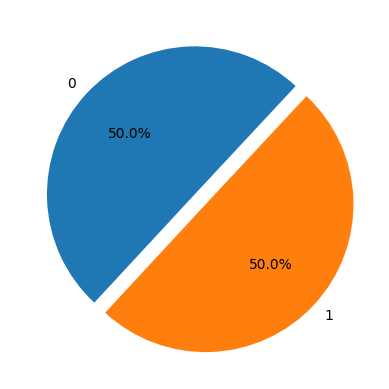

In [6]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [7]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 55765
Класс 1 : 55654


In [8]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
22,Sex_of_Casualty,"[1.0, 2.0]",2,object
21,Urban_or_Rural_Area,"[1.0, 2.0]",2,object
5,Was_Vehicle_Left_Hand_Drive?,"[1.0, 2.0]",2,object
9,Propulsion_Code,"[1.0, 2.0, 8.0, 7.0, 12.0, 6.0, 5.0, 10.0]",8,float64
7,Age_Band_of_Driver,"[6.0, 8.0, 7.0, 5.0, 4.0, 9.0, 10.0, 11.0, 3.0]",9,float64
28,Casualty_IMD_Decile,"[7.0, 2.0, 8.0, 6.0, 10.0, 4.0, 3.0, 9.0, 5.0,...",10,object
26,Pedestrian_Movement,"[0.0, 1.0, 9.0, 3.0, 2.0, 5.0, 4.0, 8.0, 7.0, ...",10,float64
2,Vehicle_Location-Restricted_Lane,"[0.0, 9.0, 2.0, 6.0, 5.0, 1.0, 7.0, 3.0, 8.0, ...",10,float64
24,Age_Band_of_Casualty,"[6.0, 11.0, 5.0, 7.0, 8.0, 4.0, 3.0, 2.0, 10.0...",11,float64
25,Pedestrian_Location,"[0.0, 5.0, 1.0, 10.0, 6.0, 4.0, 9.0, 8.0, 2.0,...",11,float64


In [9]:
num_cols = ['Vehicle_Type', 'Vehicle_Manoeuvre', 'Vehicle_Location-Restricted_Lane',
            'Hit_Object_in_Carriageway', 'Hit_Object_off_Carriageway', 'Age_of_Driver',
            'Age_Band_of_Driver', 'Engine_Capacity_(CC)', 'Propulsion_Code', 'Age_of_Vehicle',
            'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude',
            'Police_Force', 'Number_of_Vehicles', 'Number_of_Casualties',
            'Local_Authority_(District)', '1st_Road_Number', '2nd_Road_Number',
            'Age_of_Casualty', 'Age_Band_of_Casualty', 'Pedestrian_Location',
            'Pedestrian_Movement', 'Casualty_Type']

cat_cols = ['Was_Vehicle_Left_Hand_Drive?', 'Sex_of_Casualty', 'Casualty_IMD_Decile', 'Urban_or_Rural_Area']